In [1]:
# import libraries
from getpass import getpass
import numpy as np
import matplotlib.pyplot as plt
import os
import xarray as xr
from datetime import datetime,timedelta
from shapely.geometry import Polygon, Point, box, MultiPoint
from shapely.ops import unary_union
from shapely.affinity import affine_transform
import rasterio
from rasterio.control import GroundControlPoint
from rasterio.features import rasterize
from affine import Affine
import xml.etree.ElementTree as ET
import geopandas as gpd
import zipfile
import tempfile
import re
from eodms_api_client import EodmsAPI
from scipy.interpolate import interp1d
import shutil

c:\Users\Niloo\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Retrieve and Download the RCM images

In [9]:
# Sentinel-1 shapefile path
shapefile_folder = "./AI4Arctic_shapefiles"

# get EODMS user credentials
username = input("EODMS username: ")
password = getpass("EODMS password: ")

# extract time range from filename
def extract_time_range(filename):
    match = re.search(r'_(\d{8}T\d{6})_(\d{8}T\d{6})_', filename)
    start = datetime.strptime(match.group(1), "%Y%m%dT%H%M%S")
    end = datetime.strptime(match.group(2), "%Y%m%dT%H%M%S")
    return (start - timedelta(hours=5)).strftime("%Y-%m-%d"), (end + timedelta(hours=5)).strftime("%Y-%m-%d")

for zip_file in os.listdir(shapefile_folder):
    zip_path = os.path.join(shapefile_folder, zip_file)
    print(f"\n{zip_file}")

    # extract date range and prefix
    start_date, end_date = extract_time_range(zip_file)
    print(f"Buffered Time Range: {start_date} to {end_date}")
    prefix_match = re.match(r"(\d+)_", zip_file)
    prefix = prefix_match.group(1) if prefix_match else "unknown"

    with tempfile.TemporaryDirectory() as tmpdir:
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(tmpdir)
        shp_file = [f for f in os.listdir(tmpdir) if f.endswith('.shp')][0]
        shp_path = os.path.join(tmpdir, shp_file)
        geojson_path = shp_path.replace('.shp', '.geojson')
        gdf = gpd.read_file(shp_path)
        gdf.to_file(geojson_path, driver="GeoJSON")

        # connect to EODMS API and query
        client = EodmsAPI(collection='RCM', username=username, password=password)
        client.query(start=start_date, end=end_date, geometry=geojson_path)
        print(f"Found {len(client.results)} scenes.")
        if len(client.results) == 0:
            print("No scenes found")
            continue

        # filter by polarization (Only HH, HV)
        filtered = client.results[client.results["Polarization"].str.contains("HH") | client.results["Polarization"].str.contains("HV")]
        print(f"The number of scenes with HH & HV channels: {len(filtered)}")
        if filtered.empty:
            print("No HH/HV scenes to order.")
            continue

        # save filtered results
        filtered_path = f"./rcm_filtered_results/{prefix}_filtered_results.geojson"
        os.makedirs(os.path.dirname(filtered_path), exist_ok=True)
        filtered.to_file(filtered_path, driver="GeoJSON")

        # submit order
        record_ids = filtered["EODMS RecordId"].tolist()
        order_ids = client.order(record_ids)

        # save order IDs
        order_dir = "./order_ids"
        os.makedirs(order_dir, exist_ok=True)
        order_file_path = os.path.join(order_dir, f"{prefix}_RCM.txt")
        with open(order_file_path, "w") as f:
            f.write(str(order_ids[0]))

2025-05-21 11:50:37 | pyogrio._io     | INFO     | Created 1 records



01_S1A_EW_GRDM_1SDH_20190819T153633_20190819T153733_028640_033D98_D165_icechart_cis_SGRDIWA_20190819T1533Z_pl_a.zip
Buffered Time Range: 2019-08-19 to 2019-08-19


2025-05-21 11:50:39 | eodmsapi.main   | WARNING  | No results found
2025-05-21 11:50:39 | pyogrio._io     | INFO     | Created 1 records


Found 0 scenes.
No scenes found

02_S1A_EW_GRDM_1SDH_20190826T152818_20190826T152918_028742_034127_A43C_icechart_cis_SGRDIWA_20190826T1528Z_pl_a.zip
Buffered Time Range: 2019-08-26 to 2019-08-26


2025-05-21 11:50:41 | eodmsapi.main   | WARNING  | No results found
2025-05-21 11:50:41 | pyogrio._io     | INFO     | Created 1 records


...

Found 17 scenes.
The number of scenes with HH & HV channels: 17


2025-05-21 11:51:41 | pyogrio._io     | INFO     | Created 1 records



22_S1B_EW_GRDM_1SDH_20210919T153556_20210919T153656_028769_036EEE_E176_icechart_cis_SGRDIWA_20210919T1529Z_pl_a.zip
Buffered Time Range: 2021-09-19 to 2021-09-19


Fetching result metadata: 100%|██████████| 18/18 [00:01<00:00, 10.91item/s]
2025-05-21 11:51:44 | pyogrio._io     | INFO     | Created 18 records
2025-05-21 11:51:44 | eodmsapi.main   | INFO     | Submitting order for 18 items


Found 18 scenes.
The number of scenes with HH & HV channels: 18


In [27]:
# connect to EODMS
username = input("EODMS username: ")
password = getpass("EODMS password: ")
client = EodmsAPI(collection='RCM', username=username, password=password)

rcm_download_root = "./RCM"
os.makedirs(rcm_download_root, exist_ok=True)

for order_file in os.listdir(order_dir):
    order_file_path = os.path.join(order_dir, order_file)

    with open(order_file_path, "r") as f:
        order_id = int(f.read().strip())

    prefix = order_file.split("_")[0]
    scene_download_folder = os.path.join(rcm_download_root, f"{prefix}_RCM")
    os.makedirs(scene_download_folder, exist_ok=True)

    client.download([order_id], scene_download_folder)
    print(f"Download complete! Files saved to: {scene_download_folder}")

2025-05-21 14:27:40 | eodmsapi.main   | INFO     | Checking status of 1 order
2025-05-21 14:27:44 | eodmsapi.main   | INFO     | 17/17 items ready for download
2025-05-21 14:27:44 | eodmsapi.main   | INFO     | 0/17 items exist locally
2025-05-21 14:27:44 | eodmsapi.main   | INFO     | Downloading 17 remote items
RCM1_OK1192826_PK1281532_1_SC50MB_20200922_172108_HH_HV_GRD.zip: 100%|██████████| 1.92G/1.92G [00:39<00:00, 52.4MB/s]
RCM2_OK1192826_PK1281561_2_SC50MB_20200922_164602_HH_HV_GRD.zip: 100%|██████████| 1.87G/1.87G [00:35<00:00, 57.3MB/s]
RCM1_OK1161765_PK1281521_1_SC50MB_20200922_172108_HH_HV_GRD.zip: 100%|██████████| 878M/878M [00:15<00:00, 60.5MB/s] 
RCM3_OK1161765_PK1281530_1_SC50MB_20200922_161601_HH_HV_GRD.zip: 100%|██████████| 1.42G/1.42G [00:33<00:00, 45.8MB/s]
RCM3_OK1192826_PK1281544_1_SC50MB_20200922_161601_HH_HV_GRD.zip: 100%|██████████| 1.92G/1.92G [00:42<00:00, 49.1MB/s]
RCM2_OK1161765_PK1281549_1_SC50MB_20200922_164602_HH_HV_GRD.zip: 100%|██████████| 163M/163M [00:

Download complete! Files saved to: ./RCM\21_RCM


2025-05-21 14:37:18 | eodmsapi.main   | INFO     | 18/18 items ready for download
2025-05-21 14:37:18 | eodmsapi.main   | INFO     | 0/18 items exist locally
2025-05-21 14:37:18 | eodmsapi.main   | INFO     | Downloading 18 remote items
RCM2_OK1533361_PK1787889_1_SC50MB_20210919_152859_HH_HV_GRD.zip: 100%|██████████| 1.23G/1.23G [00:37<00:00, 35.0MB/s]
RCM1_OK1533334_PK1787916_1_SC50MB_20210919_160032_HH_HV_GRD.zip: 100%|██████████| 445M/445M [00:15<00:00, 29.6MB/s] 
RCM2_OK1529966_PK1787888_1_SC50MB_20210919_152859_HH_HV_GRD.zip: 100%|██████████| 1.30G/1.30G [00:40<00:00, 34.4MB/s]
RCM1_OK1533361_PK1787911_1_SC50MB_20210919_160032_HH_HV_GRD.zip: 100%|██████████| 1.09G/1.09G [00:37<00:00, 30.9MB/s]
RCM1_OK1529966_PK1787910_3_SC50MB_20210919_160032_HH_HV_GRD.zip: 100%|██████████| 1.26G/1.26G [00:41<00:00, 32.9MB/s]
RCM1_OK1529966_PK1787910_2_SC50MB_20210919_160032_HH_HV_GRD.zip: 100%|██████████| 1.31G/1.31G [00:36<00:00, 38.8MB/s]
RCM1_OK1529966_PK1787407_1_SC50MB_20210919_012439_HH_HV_

Download complete! Files saved to: ./RCM\22_RCM


In [28]:
# unzip the RCM compress files
for folder_name in os.listdir(rcm_download_root):
    folder_path = os.path.join(rcm_download_root, folder_name)
    if not os.path.isdir(folder_path):
        continue
    print(f"{folder_path}")
    for zip_name in os.listdir(folder_path):
        if zip_name.endswith(".zip"):
            zip_path = os.path.join(folder_path, zip_name)
            extract_folder = os.path.join(folder_path, zip_name.replace(".zip", ""))
            if not os.path.exists(extract_folder):
                with zipfile.ZipFile(zip_path, 'r') as zip_ref:
                    zip_ref.extractall(extract_folder)
                    print(f"Extracted:{zip_name}")
                os.remove(zip_path)

./RCM\12_RCM
./RCM\13_RCM
./RCM\14_RCM
./RCM\18_RCM
./RCM\19_RCM
./RCM\20_RCM
./RCM\21_RCM
Extracted:RCM1_OK1161765_PK1280919_1_SC50MA_20200922_024430_HH_HV_GRD.zip
Extracted:RCM1_OK1161765_PK1280919_2_SC50MA_20200922_024430_HH_HV_GRD.zip
Extracted:RCM1_OK1161765_PK1281521_1_SC50MB_20200922_172108_HH_HV_GRD.zip
Extracted:RCM1_OK1192826_PK1280950_1_SC50MA_20200922_024430_HH_HV_GRD.zip
Extracted:RCM1_OK1192826_PK1280950_2_SC50MA_20200922_024430_HH_HV_GRD.zip
Extracted:RCM1_OK1192826_PK1280951_1_SC100MA_20200922_042124_HH_HV_GRD.zip
Extracted:RCM1_OK1192826_PK1281532_1_SC50MB_20200922_172108_HH_HV_GRD.zip
Extracted:RCM2_OK1161765_PK1281548_1_SC50MB_20200922_164911_HH_HV_GRD.zip
Extracted:RCM2_OK1161765_PK1281549_1_SC50MB_20200922_164602_HH_HV_GRD.zip
Extracted:RCM2_OK1161765_PK1282750_1_SC50MB_20200922_164602_HH_HV_GRD.zip
Extracted:RCM2_OK1192826_PK1280925_2_SC50MD_20200922_021226_HH_HV_GRD.zip
Extracted:RCM2_OK1192826_PK1281561_2_SC50MB_20200922_164602_HH_HV_GRD.zip
Extracted:RCM2_OK119

Find the RCM Image with the Most Overlapping Area with Sentinel-1

In [2]:
# extract geo coordinates of RCM images (product.xml)
rcm_download_root = "./RCM"
rcm_polygons = []

for order_folder in os.listdir(rcm_download_root):
    order_path = os.path.join(rcm_download_root, order_folder)

    for scene_folder in os.listdir(order_path):
        scene_path = os.path.join(order_path, scene_folder)
        product_xml_path = os.path.join(scene_path, scene_folder, "metadata", "product.xml")
        tree = ET.parse(product_xml_path)
        root = tree.getroot()
        ns = {'ns': root.tag.split('}')[0].strip('{')}
        geo_coords = root.findall(".//ns:geodeticCoordinate", namespaces=ns)

        corner_points = []
        for coord in geo_coords:
            lat_elem = coord.find("ns:latitude", namespaces=ns)
            lon_elem = coord.find("ns:longitude", namespaces=ns)
            if lat_elem is not None and lon_elem is not None:
                lat = float(lat_elem.text)
                lon = float(lon_elem.text)
                corner_points.append((lon, lat))

        if len(corner_points) > 2:
            # convex hull (bounding box doesn't work here)
            footprint = MultiPoint(corner_points).convex_hull
            rcm_polygons.append({'order_folder': order_folder,'scene_folder': scene_folder,'footprint': footprint })

unique_folders = sorted(set(item['order_folder'] for item in rcm_polygons))
for folder in unique_folders:
    print(f"\nFolder: {folder}")
    for rcm_polygon in rcm_polygons:
        if rcm_polygon['order_folder'] == folder:
            print(rcm_polygon)


Folder: 12_RCM
{'order_folder': '12_RCM', 'scene_folder': 'RCM1_OK1147912_PK1196434_1_SC50MB_20200810_014715_HH_HV_GRD', 'footprint': <POLYGON ((-130.018 68.83, -134.788 73.455, -133.887 73.547, -132.978 73.635...>}

Folder: 13_RCM
{'order_folder': '13_RCM', 'scene_folder': 'RCM2_OK1192826_PK1262101_1_SC50MA_20200919_162153_HH_HV_GRD', 'footprint': <POLYGON ((-135.228 73.811, -146.684 74.814, -146.455 75.087, -146.214 75.35...>}

Folder: 14_RCM
{'order_folder': '14_RCM', 'scene_folder': 'RCM2_OK1161765_PK1291421_1_SC50MB_20200927_025229_HH_HV_GRD', 'footprint': <POLYGON ((-148.137 71.1, -152.454 74.628, -151.499 74.725, -150.531 74.818,...>}

Folder: 18_RCM
{'order_folder': '18_RCM', 'scene_folder': 'RCM2_OK1132487_PK1192891_1_SC50MB_20200807_152930_HH_HV_GRD', 'footprint': <POLYGON ((-128.328 70.112, -137.815 70.834, -137.686 71.116, -137.554 71.39...>}

Folder: 19_RCM
{'order_folder': '19_RCM', 'scene_folder': 'RCM3_OK1161765_PK1279068_1_SC50MB_20200920_160034_HH_HV_GRD', 'footprint

In [3]:
sentinel1_data_folder = "./AI4Arctic"
shapefile_folder = "./AI4Arctic_shapefiles"
rcm_download_root = "./RCM"

sentinel_footprints = []

# get RCM folders by prefix number
available_rcm_folders = {
    f.split("_")[0] for f in os.listdir(rcm_download_root)
    if os.path.isdir(os.path.join(rcm_download_root, f)) and f.endswith("_RCM")
}

for shapefile_zip in os.listdir(shapefile_folder):
    match = re.match(r"(\d+)_([^.]+)\.zip", shapefile_zip)
    shapefile_number = match.group(1)         
    shapefile_base = match.group(2)         

    # check if shapefile's prefix number matches an available RCM folder
    if shapefile_number not in available_rcm_folders:
        continue

    # find matching .nc file with same base name
    matched_nc = None
    for nc_file in os.listdir(sentinel1_data_folder):
        if nc_file.endswith(".nc") and shapefile_base in nc_file:
            matched_nc = os.path.join(sentinel1_data_folder, nc_file)
            break

    matching_rcm_folder = next(f for f in available_rcm_folders if f == shapefile_number)
    print(f"\nFolder: {shapefile_number}")

    # extract coordinates of the Sntinel-1
    ds = xr.open_dataset(matched_nc)
    lat = ds['sar_grid_latitude'].values
    lon = ds['sar_grid_longitude'].values
    lat_flat = lat.flatten()
    lon_flat = lon.flatten()
    valid_mask = np.isfinite(lat_flat) & np.isfinite(lon_flat)
    points = MultiPoint(list(zip(lon_flat[valid_mask], lat_flat[valid_mask])))
    sentinel_footprint = points.convex_hull

    sentinel_footprints.append({
        'shapefile': shapefile_zip,
        'rcm_folder': f"{matching_rcm_folder}_RCM",
        'base_name': os.path.basename(matched_nc),
        'footprint': sentinel_footprint
    })

    print(f"  Sentinel: {os.path.basename(matched_nc)}")
    print(f"  Footprint: {sentinel_footprints[-1]}") 



Folder: 12
  Sentinel: S1A_EW_GRDM_1SDH_20200810T151258_20200810T151357_033846_03ECB0_0878_icechart_cis_SGRDIWA_20200810T1522Z_pl_a.nc
  Footprint: {'shapefile': '12_S1A_EW_GRDM_1SDH_20200810T151258_20200810T151357_033846_03ECB0_0878_icechart_cis_SGRDIWA_20200810T1522Z_pl_a.zip', 'rcm_folder': '12_RCM', 'base_name': 'S1A_EW_GRDM_1SDH_20200810T151258_20200810T151357_033846_03ECB0_0878_icechart_cis_SGRDIWA_20200810T1522Z_pl_a.nc', 'footprint': <POLYGON ((-124.054 66.817, -133.499 67.683, -133.463 67.766, -133.386 67.94...>}

Folder: 13
  Sentinel: S1A_EW_GRDM_1SDH_20200919T161650_20200919T161759_034430_04014D_1137_icechart_cis_SGRDIWA_20200919T1624Z_pl_a.nc
  Footprint: {'shapefile': '13_S1A_EW_GRDM_1SDH_20200919T161650_20200919T161759_034430_04014D_1137_icechart_cis_SGRDIWA_20200919T1624Z_pl_a.zip', 'rcm_folder': '13_RCM', 'base_name': 'S1A_EW_GRDM_1SDH_20200919T161650_20200919T161759_034430_04014D_1137_icechart_cis_SGRDIWA_20200919T1624Z_pl_a.nc', 'footprint': <POLYGON ((-133.785 73.0

In [4]:
best_RCM_match = []

# calculate overlaps between Sentinel-1 and RCM scenes
for sentinel_scene in sentinel_footprints:
    sentinel_footprint = sentinel_scene['footprint']
    sentinel_name = sentinel_scene['shapefile']

    overlaps = []

    for rcm_scene in rcm_polygons:
        if rcm_scene['order_folder'] != sentinel_scene['rcm_folder']:
            continue

        rcm_polygon = rcm_scene['footprint']

        intersection_area = rcm_polygon.intersection(sentinel_footprint).area
        rcm_area = rcm_polygon.area
        sentinel_area = sentinel_footprint.area

        overlaps.append({
            'sentinel_file': sentinel_name,
            'rcm_folder': rcm_scene['order_folder'],
            'rcm_scene': rcm_scene['scene_folder'],
            'overlap_area': intersection_area,
            'overlap_percent_rcm': (intersection_area / rcm_area) * 100,
            'overlap_percent_sentinel': (intersection_area / sentinel_area) * 100
        })

    overlaps_sorted = sorted(overlaps, key=lambda x: x['overlap_area'], reverse=True)
    if overlaps_sorted:
        best_match = overlaps_sorted[:1]
        print(f"\nBest RCM match for Sentinel-1: {sentinel_name}")
        for i, match in enumerate(best_match, 1):
            print(f"\n    RCM Scene: {match['rcm_folder']}/{match['rcm_scene']}")
            print(f"    Overlap Area: {match['overlap_area']:.4f}")
            print(f"    Overlap % of RCM: {match['overlap_percent_rcm']:.2f}%")
            print(f"    Overlap % of Sentinel-1: {match['overlap_percent_sentinel']:.2f}%")
            best_path = os.path.join(rcm_download_root, match['rcm_folder'], match['rcm_scene'],match['rcm_scene'])
            best_RCM_match.append(best_path)

print("\n", best_RCM_match)



Best RCM match for Sentinel-1: 12_S1A_EW_GRDM_1SDH_20200810T151258_20200810T151357_033846_03ECB0_0878_icechart_cis_SGRDIWA_20200810T1522Z_pl_a.zip

    RCM Scene: 12_RCM/RCM1_OK1147912_PK1196434_1_SC50MB_20200810_014715_HH_HV_GRD
    Overlap Area: 15.6928
    Overlap % of RCM: 30.49%
    Overlap % of Sentinel-1: 41.48%

Best RCM match for Sentinel-1: 13_S1A_EW_GRDM_1SDH_20200919T161650_20200919T161759_034430_04014D_1137_icechart_cis_SGRDIWA_20200919T1624Z_pl_a.zip

    RCM Scene: 13_RCM/RCM2_OK1192826_PK1262101_1_SC50MA_20200919_162153_HH_HV_GRD
    Overlap Area: 49.4026
    Overlap % of RCM: 65.50%
    Overlap % of Sentinel-1: 75.85%

Best RCM match for Sentinel-1: 14_S1A_EW_GRDM_1SDH_20200927T165045_20200927T165146_034547_040561_1061_icechart_cis_SGRDIWA_20200927T1657Z_pl_a.zip

    RCM Scene: 14_RCM/RCM2_OK1161765_PK1291421_1_SC50MB_20200927_025229_HH_HV_GRD
    Overlap Area: 21.8272
    Overlap % of RCM: 50.40%
    Overlap % of Sentinel-1: 46.84%

Best RCM match for Sentinel-1: 18

In [32]:
# remove other RCM scenes 
best_rcm_scene_dirs = set()
for path in best_RCM_match:
    parts = os.path.normpath(path).split(os.sep)
    rcm_folder = parts[-3]
    rcm_scene = parts[-2]
    full_path = os.path.join(rcm_download_root, rcm_folder, rcm_scene)
    best_rcm_scene_dirs.add(full_path)

rcm_root = os.path.join(rcm_download_root)
for folder_name in os.listdir(rcm_root):
    folder_path = os.path.join(rcm_root, folder_name)
    if not os.path.isdir(folder_path):
        continue
    for scene_name in os.listdir(folder_path):
        scene_path = os.path.join(folder_path, scene_name)
        if not os.path.isdir(scene_path):
            continue
        if scene_path not in best_rcm_scene_dirs:
            print(f"Deleting: {scene_path}")
            shutil.rmtree(scene_path)

Deleting: ./RCM\21_RCM\RCM1_OK1161765_PK1280919_1_SC50MA_20200922_024430_HH_HV_GRD
Deleting: ./RCM\21_RCM\RCM1_OK1161765_PK1280919_2_SC50MA_20200922_024430_HH_HV_GRD
Deleting: ./RCM\21_RCM\RCM1_OK1161765_PK1281521_1_SC50MB_20200922_172108_HH_HV_GRD
Deleting: ./RCM\21_RCM\RCM1_OK1192826_PK1280950_1_SC50MA_20200922_024430_HH_HV_GRD
Deleting: ./RCM\21_RCM\RCM1_OK1192826_PK1280950_2_SC50MA_20200922_024430_HH_HV_GRD
Deleting: ./RCM\21_RCM\RCM1_OK1192826_PK1281532_1_SC50MB_20200922_172108_HH_HV_GRD
Deleting: ./RCM\21_RCM\RCM2_OK1161765_PK1281548_1_SC50MB_20200922_164911_HH_HV_GRD
Deleting: ./RCM\21_RCM\RCM2_OK1161765_PK1281549_1_SC50MB_20200922_164602_HH_HV_GRD
Deleting: ./RCM\21_RCM\RCM2_OK1161765_PK1282750_1_SC50MB_20200922_164602_HH_HV_GRD
Deleting: ./RCM\21_RCM\RCM2_OK1192826_PK1280925_2_SC50MD_20200922_021226_HH_HV_GRD
Deleting: ./RCM\21_RCM\RCM2_OK1192826_PK1281561_2_SC50MB_20200922_164602_HH_HV_GRD
Deleting: ./RCM\21_RCM\RCM2_OK1192826_PK1282751_2_SC50MB_20200922_164602_HH_HV_GRD
Dele

In [5]:
# Calibration into Sigma nought
def calibrate_sigma0(tiff_path, lut_path):
    with rasterio.open(tiff_path) as src:
        dn = src.read(1).astype(np.float32)
        tags = src.tags()
        profile = src.profile
        if src.nodata is not None:
            dn = np.ma.masked_equal(dn, src.nodata)
    tree = ET.parse(lut_path)
    root = tree.getroot()
    ns = {'ns': root.tag.split('}')[0].strip('{')}
    gains_elem = root.find("ns:gains", ns)
    gains_text = gains_elem.text.strip()
    gains = np.array(list(map(float, gains_text.split())))
    step_size_elem = root.find("ns:stepSize", ns)
    step_size = int(step_size_elem.text.strip())
    height, width = dn.shape
    num_values = len(gains)
    if step_size < 0:
        start_row = int(root.find("ns:pixelFirstLutValue", ns).text.strip())
        lut_rows = np.arange(start_row, start_row + step_size * num_values, step_size)
        gains = gains[::-1]
    else:
        lut_rows = np.arange(0, height, step_size)
    lut_rows = lut_rows[:len(gains)]
    interp_func = interp1d(lut_rows, gains[:len(lut_rows)], kind='linear', fill_value='extrapolate')
    gains_full = interp_func(np.arange(height))
    lut_2d = np.tile(gains_full[:, np.newaxis], (1, width))
    sigma0_linear = (dn ** 2) / lut_2d
    sigma0_dB = 10 * np.log10(sigma0_linear + 1e-10)
    return sigma0_dB, profile, tags
 
 
for folder_path in best_RCM_match:
    folder_name = os.path.basename(folder_path)        
    order_folder = os.path.basename(os.path.dirname(folder_path))
    folder_root = folder_path
    imagery_path = os.path.join(folder_root, 'imagery')
    calibration_path = os.path.join(folder_root, 'metadata', 'calibration')
    hh_files = [f for f in os.listdir(imagery_path) if 'HH' in f and f.endswith('.tif')]
    hv_files = [f for f in os.listdir(imagery_path) if 'HV' in f and f.endswith('.tif')]
    hh_path = os.path.join(imagery_path, hh_files[0])
    hv_path = os.path.join(imagery_path, hv_files[0])
    lut_hh_path = os.path.join(calibration_path, "lutSigma_HH.xml")
    lut_hv_path = os.path.join(calibration_path, "lutSigma_HV.xml")
 
 
    # Calibrate HH, HV
    sigma0_dB_HH, profile_HH, tags_HH = calibrate_sigma0(hh_path, lut_hh_path)
    sigma0_dB_HV, profile_HV, tags_HV = calibrate_sigma0(hv_path, lut_hv_path)
 

    print(f"\n[HH] {folder_name}")
    print(f" - Min: {sigma0_dB_HH.min():.2f} dB")
    print(f" - Max: {sigma0_dB_HH.max():.2f} dB")
    print(f" - Mean: {sigma0_dB_HH.mean():.2f} dB")
    print(f" - DataType: {sigma0_dB_HH.dtype}")
    print(f"\n[HV] {folder_name}")
    print(f" - Min: {sigma0_dB_HV.min():.2f} dB")
    print(f" - Max: {sigma0_dB_HV.max():.2f} dB")
    print(f" - Mean: {sigma0_dB_HV.mean():.2f} dB")
    print(f" - DataType: {sigma0_dB_HV.dtype}")


    calibrated_dir = os.path.join(folder_root, 'calibrated_imagery')
    os.makedirs(calibrated_dir, exist_ok=True)
    # Save HH
    profile_HH.update(dtype='float32', count=1, compress='lzw')
    save_path_HH = os.path.join(calibrated_dir, f"{folder_name}_sigma0_HH_dB.tif")
    with rasterio.open(save_path_HH, 'w', **profile_HH) as dst:
        dst.write(sigma0_dB_HH.astype(np.float32), 1)
        dst.update_tags(**tags_HH)
    # Save HV
    profile_HV.update(dtype='float32', count=1, compress='lzw')
    save_path_HV = os.path.join(calibrated_dir, f"{folder_name}_sigma0_HV_dB.tif")
    with rasterio.open(save_path_HV, 'w', **profile_HV) as dst:
        dst.write(sigma0_dB_HV.astype(np.float32), 1)
        dst.update_tags(**tags_HV)
 
 
    # # Plot histograms
    # fig, axs = plt.subplots(1, 2, figsize=(12, 5))
    # axs[0].hist(sigma0_dB_HH.flatten(), bins=256, color='gray', edgecolor='black')
    # axs[0].set_title(f"Histogram HH - {folder_name}")
    # axs[0].set_xlabel("Backscatter (dB)")
    # axs[0].set_ylabel("Frequency")
    # axs[0].grid(True, linestyle='--', alpha=0.6)
 
    # axs[1].hist(sigma0_dB_HV.flatten(), bins=256, color='gray', edgecolor='black')
    # axs[1].set_title(f"Histogram HV - {folder_name}")
    # axs[1].set_xlabel("Backscatter (dB)")
    # axs[1].set_ylabel("Frequency")
    # axs[1].grid(True, linestyle='--', alpha=0.6)
 
    # plt.suptitle(f"Calibrated σ⁰ Histograms for {folder_name}")
    # plt.tight_layout()
    # plt.show()


[HH] RCM1_OK1147912_PK1196434_1_SC50MB_20200810_014715_HH_HV_GRD
 - Min: -100.00 dB
 - Max: 6.26 dB
 - Mean: -21.41 dB
 - DataType: float64

[HV] RCM1_OK1147912_PK1196434_1_SC50MB_20200810_014715_HH_HV_GRD
 - Min: -100.00 dB
 - Max: -1.20 dB
 - Mean: -31.07 dB
 - DataType: float64


c:\Users\Niloo\AppData\Local\Programs\Python\Python311\Lib\site-packages\rasterio\__init__.py:378: NotGeoreferencedWarning: The given matrix is equal to Affine.identity or its flipped counterpart. GDAL may ignore this matrix and save no geotransform without raising an error. This behavior is somewhat driver-specific.
  dataset = writer(



[HH] RCM2_OK1192826_PK1262101_1_SC50MA_20200919_162153_HH_HV_GRD
 - Min: -100.00 dB
 - Max: 7.95 dB
 - Mean: -16.66 dB
 - DataType: float64

[HV] RCM2_OK1192826_PK1262101_1_SC50MA_20200919_162153_HH_HV_GRD
 - Min: -100.00 dB
 - Max: 2.53 dB
 - Mean: -28.60 dB
 - DataType: float64

[HH] RCM2_OK1161765_PK1291421_1_SC50MB_20200927_025229_HH_HV_GRD
 - Min: -100.00 dB
 - Max: 1.19 dB
 - Mean: -21.87 dB
 - DataType: float64

[HV] RCM2_OK1161765_PK1291421_1_SC50MB_20200927_025229_HH_HV_GRD
 - Min: -100.00 dB
 - Max: -6.08 dB
 - Mean: -31.04 dB
 - DataType: float64

[HH] RCM2_OK1132487_PK1192891_1_SC50MB_20200807_152930_HH_HV_GRD
 - Min: -100.00 dB
 - Max: 4.02 dB
 - Mean: -20.65 dB
 - DataType: float64

[HV] RCM2_OK1132487_PK1192891_1_SC50MB_20200807_152930_HH_HV_GRD
 - Min: -100.00 dB
 - Max: -5.67 dB
 - Mean: -31.13 dB
 - DataType: float64

[HH] RCM3_OK1161765_PK1279068_1_SC50MB_20200920_160034_HH_HV_GRD
 - Min: -100.00 dB
 - Max: 5.24 dB
 - Mean: -16.86 dB
 - DataType: float64

[HV] RCM3_

Calculate the Overlapping and Non-overlapping polygons in Both RCM and Sentinel-1 images


Processing: ./RCM\12_RCM\RCM1_OK1147912_PK1196434_1_SC50MB_20200810_014715_HH_HV_GRD\RCM1_OK1147912_PK1196434_1_SC50MB_20200810_014715_HH_HV_GRD
Best Matching RCM Bounding box: [{'folder': 'RCM1_OK1147912_PK1196434_1_SC50MB_20200810_014715_HH_HV_GRD', 'footprint': <POLYGON ((-130.018 68.83, -134.788 73.455, -133.887 73.547, -132.978 73.635...>}]
Matching Sentinel-1 image: 12_S1A_EW_GRDM_1SDH_20200810T151258_20200810T151357_033846_03ECB0_0878_icechart_cis_SGRDIWA_20200810T1522Z_pl_a.zip
Overlap area: POLYGON ((-132.02481424941962 70.77644870421656, -131.92193770965977 70.9697973549862, -131.8264654464023 71.14758262666795, -131.26675817909256 71.11574037833562, -130.69805732755069 71.08155895640432, -130.13138071193086 71.04565167053033, -129.56681564516003 71.00802834731577, -129.00444725628333 70.9686992073124, -128.44435851768728 70.92767466925346, -127.88662995792076 70.8849656789615, -127.33133975364929 70.84058349241299, -126.77856369510353 70.79453967238892, -126.22837516495528 

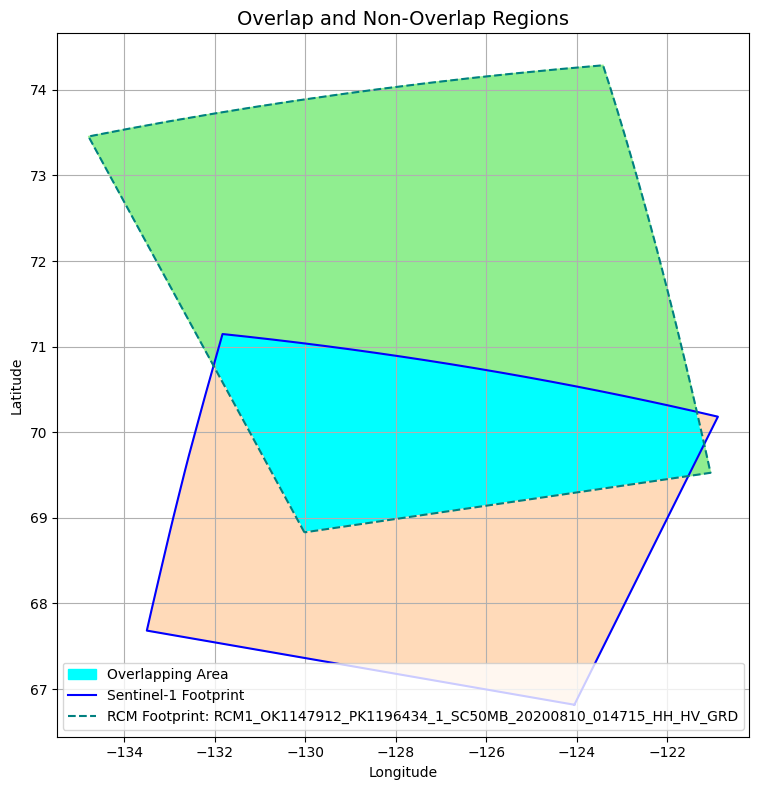

2025-05-23 15:11:21 | pyogrio._io     | INFO     | Created 1 records
2025-05-23 15:11:21 | pyogrio._io     | INFO     | Created 1 records
2025-05-23 15:11:21 | pyogrio._io     | INFO     | Created 1 records


Shapefiles saved to: ./RCM\12_RCM\RCM1_OK1147912_PK1196434_1_SC50MB_20200810_014715_HH_HV_GRD\RCM1_OK1147912_PK1196434_1_SC50MB_20200810_014715_HH_HV_GRD\shapefile_masks

Processing: ./RCM\13_RCM\RCM2_OK1192826_PK1262101_1_SC50MA_20200919_162153_HH_HV_GRD\RCM2_OK1192826_PK1262101_1_SC50MA_20200919_162153_HH_HV_GRD
Best Matching RCM Bounding box: [{'folder': 'RCM2_OK1192826_PK1262101_1_SC50MA_20200919_162153_HH_HV_GRD', 'footprint': <POLYGON ((-135.228 73.811, -146.684 74.814, -146.455 75.087, -146.214 75.35...>}]
Matching Sentinel-1 image: 13_S1A_EW_GRDM_1SDH_20200919T161650_20200919T161759_034430_04014D_1137_icechart_cis_SGRDIWA_20200919T1624Z_pl_a.zip
Overlap area: POLYGON ((-145.9811028430947 74.75269258232373, -145.89737726445804 74.86337453621766, -145.76099243051965 75.04022576002757, -145.62195572697988 75.21701598835246, -145.48017159031158 75.39374328816216, -145.33554005086899 75.57040539815124, -145.1879561020642 75.74700017207584, -145.03730971640292 75.92352518766053, -144

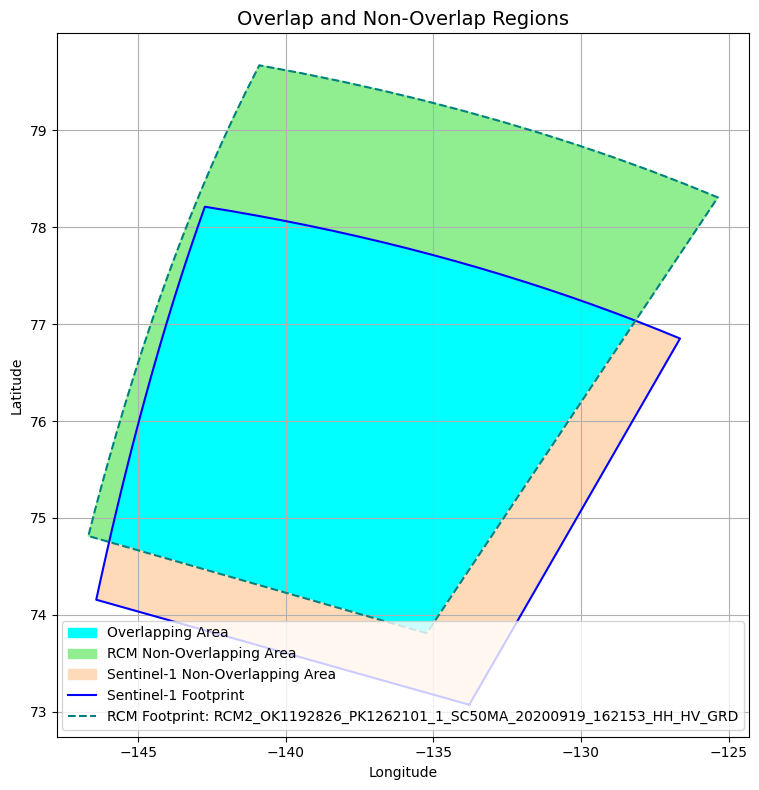

2025-05-23 15:11:22 | pyogrio._io     | INFO     | Created 1 records
2025-05-23 15:11:22 | pyogrio._io     | INFO     | Created 1 records
2025-05-23 15:11:22 | pyogrio._io     | INFO     | Created 1 records


Shapefiles saved to: ./RCM\13_RCM\RCM2_OK1192826_PK1262101_1_SC50MA_20200919_162153_HH_HV_GRD\RCM2_OK1192826_PK1262101_1_SC50MA_20200919_162153_HH_HV_GRD\shapefile_masks

Processing: ./RCM\14_RCM\RCM2_OK1161765_PK1291421_1_SC50MB_20200927_025229_HH_HV_GRD\RCM2_OK1161765_PK1291421_1_SC50MB_20200927_025229_HH_HV_GRD
Best Matching RCM Bounding box: [{'folder': 'RCM2_OK1161765_PK1291421_1_SC50MB_20200927_025229_HH_HV_GRD', 'footprint': <POLYGON ((-148.137 71.1, -152.454 74.628, -151.499 74.725, -150.531 74.818,...>}]
Matching Sentinel-1 image: 14_S1A_EW_GRDM_1SDH_20200927T165045_20200927T165146_034547_040561_1061_icechart_cis_SGRDIWA_20200927T1657Z_pl_a.zip
Overlap area: POLYGON ((-152.38287904844623 74.57009932080952, -152.20921442145072 74.55971176333476, -151.5293402881331 74.5167479930342, -150.85322251073893 74.47171951763642, -150.1810025117093 74.42464420828446, -149.51281592242506 74.37554054527652, -148.84879253370573 74.3244275581948, -148.1890563089296 74.27132473478414, -147.53

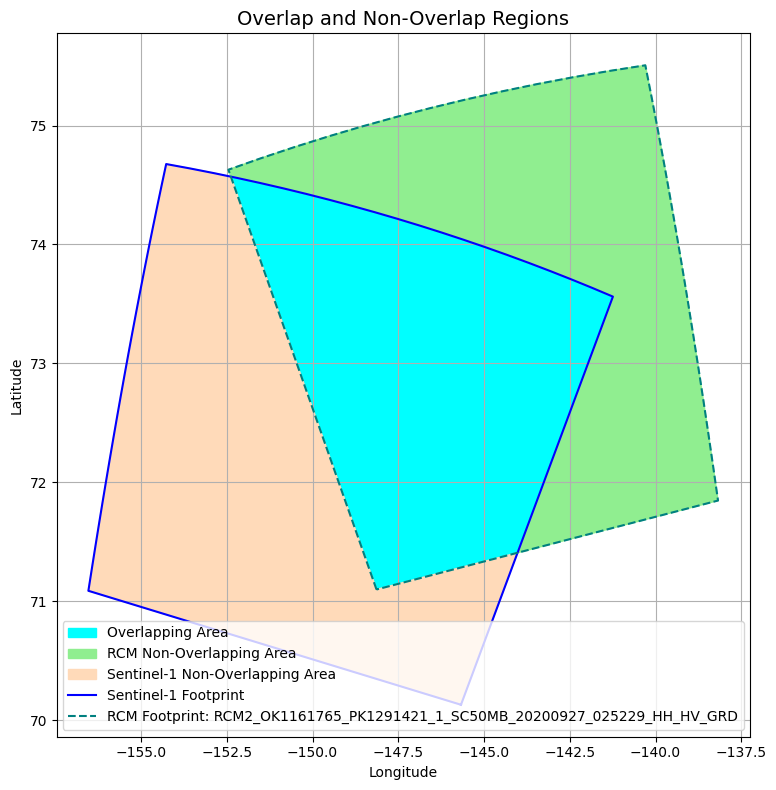

2025-05-23 15:11:22 | pyogrio._io     | INFO     | Created 1 records
2025-05-23 15:11:22 | pyogrio._io     | INFO     | Created 1 records
2025-05-23 15:11:22 | pyogrio._io     | INFO     | Created 1 records


Shapefiles saved to: ./RCM\14_RCM\RCM2_OK1161765_PK1291421_1_SC50MB_20200927_025229_HH_HV_GRD\RCM2_OK1161765_PK1291421_1_SC50MB_20200927_025229_HH_HV_GRD\shapefile_masks

Processing: ./RCM\18_RCM\RCM2_OK1132487_PK1192891_1_SC50MB_20200807_152930_HH_HV_GRD\RCM2_OK1132487_PK1192891_1_SC50MB_20200807_152930_HH_HV_GRD
Best Matching RCM Bounding box: [{'folder': 'RCM2_OK1132487_PK1192891_1_SC50MB_20200807_152930_HH_HV_GRD', 'footprint': <POLYGON ((-128.328 70.112, -137.815 70.834, -137.686 71.116, -137.554 71.39...>}]
Matching Sentinel-1 image: 18_S1B_EW_GRDM_1SDH_20200807T153548_20200807T153648_022819_02B4FC_5478_icechart_cis_SGRDIWA_20200807T1529Z_pl_a.zip
Overlap area: POLYGON ((-137.4196430652001 71.67998699194403, -137.2819742558003 71.96191033473958, -137.141170846267 72.24376729641104, -136.9970811822785 72.52555533624624, -136.8495440472082 72.80727157424361, -136.6983872613334 73.08891334782439, -136.5434271732655 73.37047745138356, -136.3844677710084 73.65196055036601, -136.221299

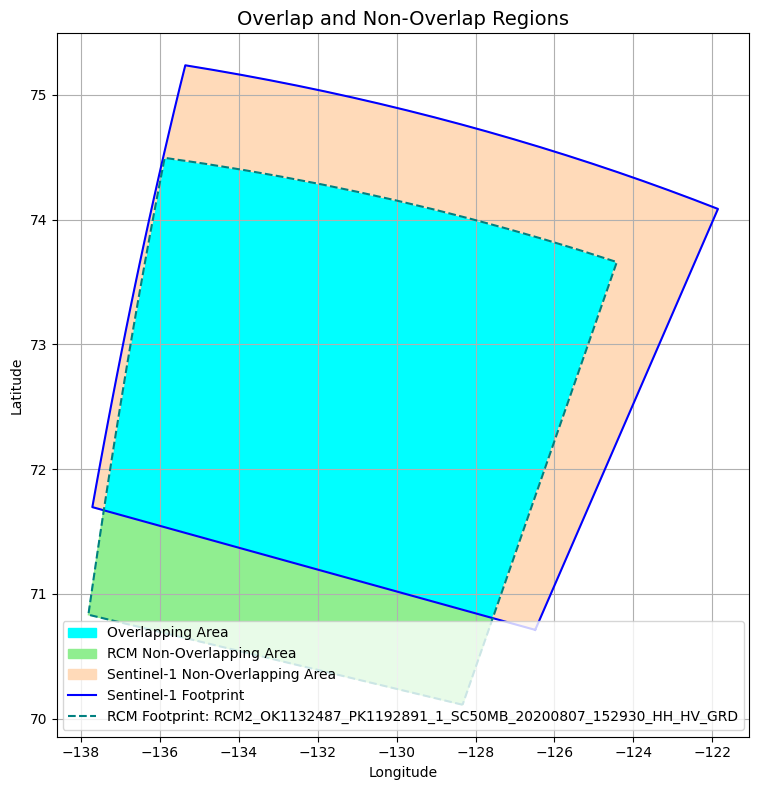

2025-05-23 15:11:22 | pyogrio._io     | INFO     | Created 1 records
2025-05-23 15:11:22 | pyogrio._io     | INFO     | Created 1 records
2025-05-23 15:11:22 | pyogrio._io     | INFO     | Created 1 records


Shapefiles saved to: ./RCM\18_RCM\RCM2_OK1132487_PK1192891_1_SC50MB_20200807_152930_HH_HV_GRD\RCM2_OK1132487_PK1192891_1_SC50MB_20200807_152930_HH_HV_GRD\shapefile_masks

Processing: ./RCM\19_RCM\RCM3_OK1161765_PK1279068_1_SC50MB_20200920_160034_HH_HV_GRD\RCM3_OK1161765_PK1279068_1_SC50MB_20200920_160034_HH_HV_GRD
Best Matching RCM Bounding box: [{'folder': 'RCM3_OK1161765_PK1279068_1_SC50MB_20200920_160034_HH_HV_GRD', 'footprint': <POLYGON ((-130.462 75.078, -142.975 75.976, -142.77 76.256, -142.555 76.537...>}]
Matching Sentinel-1 image: 19_S1B_EW_GRDM_1SDH_20200920T160733_20200920T160833_023461_02C90B_2360_icechart_cis_SGRDIWA_20200920T1600Z_pl_a.zip
Overlap area: POLYGON ((-142.96852585662037 75.97503116503623, -142.85077900974525 76.1102225744261, -142.6938434277409 76.28664085148192, -142.53348279983118 76.46298177509937, -142.3695629671728 76.63924244186417, -142.20194275503968 76.81541980674392, -142.0304735983541 76.9915105826106, -141.85499878963395 77.1675115028679, -141.675

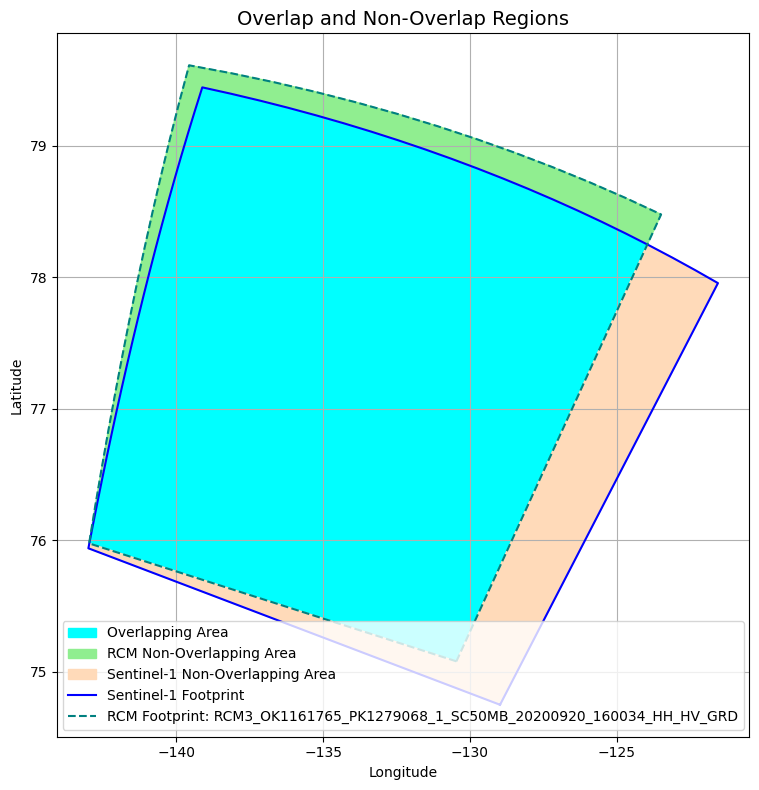

2025-05-23 15:11:23 | pyogrio._io     | INFO     | Created 1 records
2025-05-23 15:11:23 | pyogrio._io     | INFO     | Created 1 records
2025-05-23 15:11:23 | pyogrio._io     | INFO     | Created 1 records


Shapefiles saved to: ./RCM\19_RCM\RCM3_OK1161765_PK1279068_1_SC50MB_20200920_160034_HH_HV_GRD\RCM3_OK1161765_PK1279068_1_SC50MB_20200920_160034_HH_HV_GRD\shapefile_masks

Processing: ./RCM\20_RCM\RCM3_OK1161765_PK1280307_1_SC50MB_20200921_160837_HH_HV_GRD\RCM3_OK1161765_PK1280307_1_SC50MB_20200921_160837_HH_HV_GRD
Best Matching RCM Bounding box: [{'folder': 'RCM3_OK1161765_PK1280307_1_SC50MB_20200921_160837_HH_HV_GRD', 'footprint': <POLYGON ((-132.227 75.231, -144.876 76.137, -144.664 76.418, -144.446 76.69...>}]
Matching Sentinel-1 image: 20_S1B_EW_GRDM_1SDH_20200921T164824_20200921T164924_023476_02C98A_5E28_icechart_cis_SGRDIWA_20200921T1648Z_pl_a.zip
Overlap area: POLYGON ((-144.6644408079858 76.41783558647994, -144.445735254989 76.6985007980496, -144.2192708720571 76.97902060890672, -143.9845391851418 77.25938612654001, -143.7409862821144 77.53958762964207, -143.4880083172035 77.81961449858002, -143.2249459959494 78.0994551188568, -142.951077566423 78.37909674708119, -142.665611367

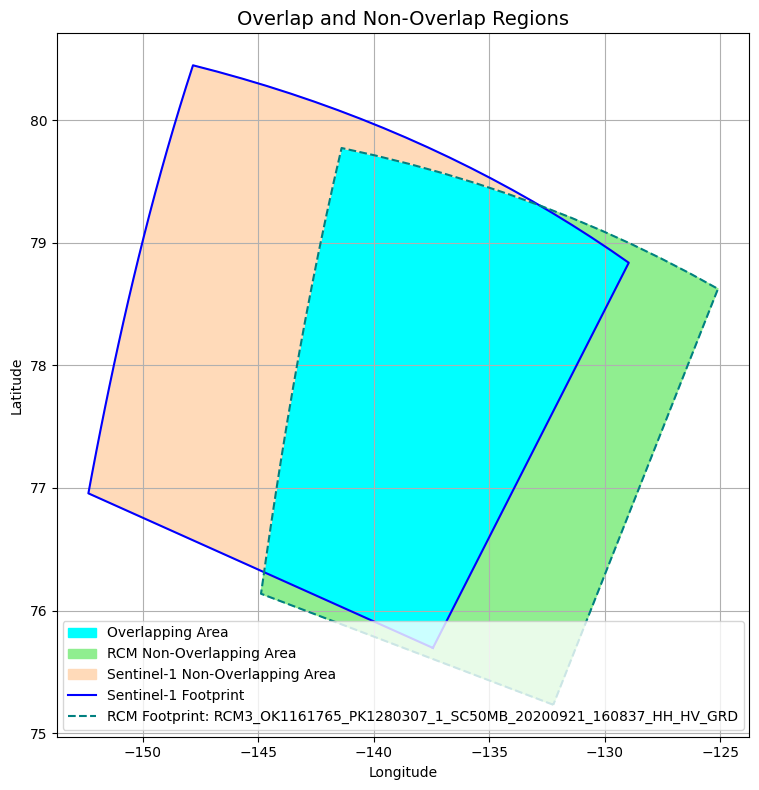

2025-05-23 15:11:23 | pyogrio._io     | INFO     | Created 1 records
2025-05-23 15:11:23 | pyogrio._io     | INFO     | Created 1 records
2025-05-23 15:11:23 | pyogrio._io     | INFO     | Created 1 records


Shapefiles saved to: ./RCM\20_RCM\RCM3_OK1161765_PK1280307_1_SC50MB_20200921_160837_HH_HV_GRD\RCM3_OK1161765_PK1280307_1_SC50MB_20200921_160837_HH_HV_GRD\shapefile_masks

Processing: ./RCM\21_RCM\RCM1_OK1192826_PK1280951_1_SC100MA_20200922_042124_HH_HV_GRD\RCM1_OK1192826_PK1280951_1_SC100MA_20200922_042124_HH_HV_GRD
Best Matching RCM Bounding box: [{'folder': 'RCM1_OK1192826_PK1280951_1_SC100MA_20200922_042124_HH_HV_GRD', 'footprint': <POLYGON ((-175.234 72.96, -179.484 75.516, -179.861 80.132, -178.393 80.756...>}]
Matching Sentinel-1 image: 21_S1B_EW_GRDM_1SDH_20200922T172924_20200922T173024_023491_02C9FB_0F67_icechart_cis_SGRDIWA_20200922T1729Z_pl_a.zip
Overlap area: POLYGON ((-162.13221299449017 77.45133968837649, -161.95067276501513 77.62216898797493, -161.75936342345636 77.79781879764171, -161.56321086542613 77.97336045831703, -161.36200304790006 78.14878921893865, -161.15551538449665 78.32410021088772, -160.9435100695663 78.4992882256038, -160.7257350036931 78.67434777317591, -1

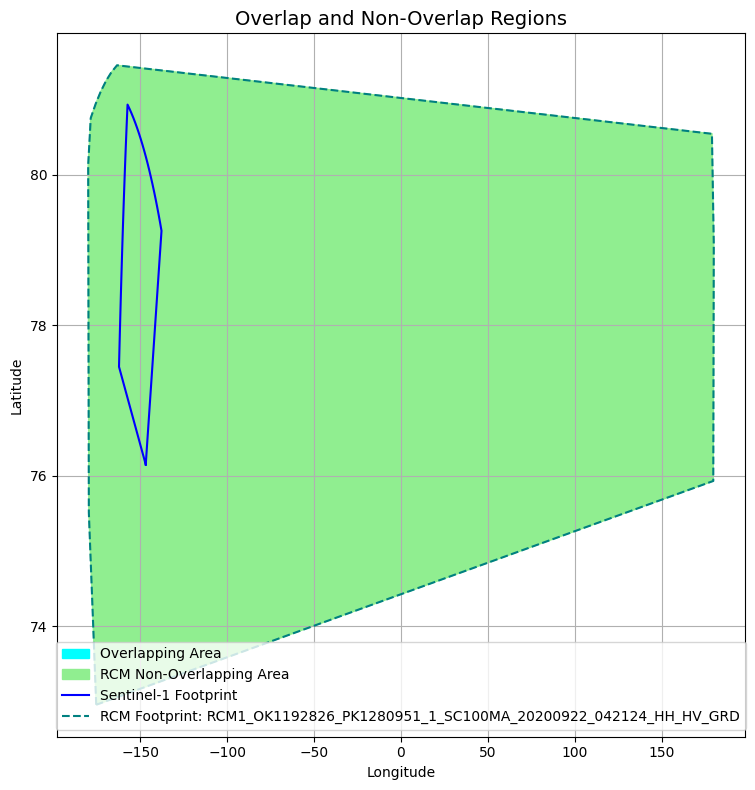

2025-05-23 15:11:24 | pyogrio._io     | INFO     | Created 1 records
2025-05-23 15:11:24 | pyogrio._io     | INFO     | Created 1 records
2025-05-23 15:11:24 | pyogrio._io     | INFO     | Created 1 records


Shapefiles saved to: ./RCM\21_RCM\RCM1_OK1192826_PK1280951_1_SC100MA_20200922_042124_HH_HV_GRD\RCM1_OK1192826_PK1280951_1_SC100MA_20200922_042124_HH_HV_GRD\shapefile_masks

Processing: ./RCM\22_RCM\RCM2_OK1529966_PK1787888_2_SC50MB_20210919_152859_HH_HV_GRD\RCM2_OK1529966_PK1787888_2_SC50MB_20210919_152859_HH_HV_GRD
Best Matching RCM Bounding box: [{'folder': 'RCM2_OK1529966_PK1787888_2_SC50MB_20210919_152859_HH_HV_GRD', 'footprint': <POLYGON ((-128.11 70.346, -137.705 71.073, -137.575 71.356, -137.44 71.639,...>}]
Matching Sentinel-1 image: 22_S1B_EW_GRDM_1SDH_20210919T153556_20210919T153656_028769_036EEE_E176_icechart_cis_SGRDIWA_20210919T1529Z_pl_a.zip
Overlap area: POLYGON ((-137.3026671695992 71.92147193863511, -137.1620082372833 72.20398441501703, -137.0180704645977 72.48642802986136, -136.870692770303 72.76880007128152, -136.7197034584002 73.05109763836542, -136.5649192854369 73.33331771096394, -136.4061446267197 73.61545687483779, -136.2431702864003 73.89751151665305, -136.0757

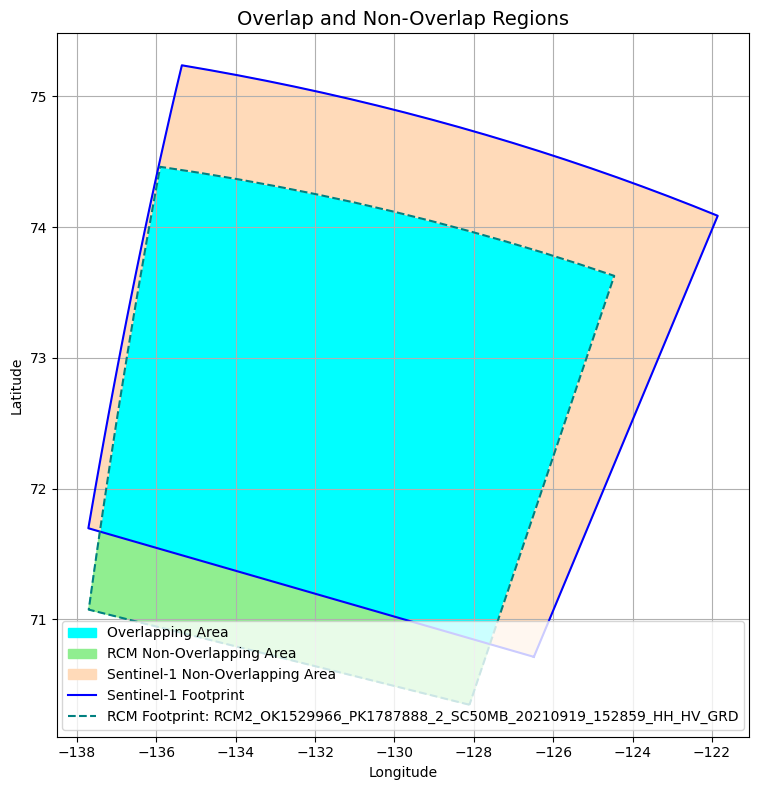

2025-05-23 15:11:24 | pyogrio._io     | INFO     | Created 1 records
2025-05-23 15:11:24 | pyogrio._io     | INFO     | Created 1 records
2025-05-23 15:11:24 | pyogrio._io     | INFO     | Created 1 records


Shapefiles saved to: ./RCM\22_RCM\RCM2_OK1529966_PK1787888_2_SC50MB_20210919_152859_HH_HV_GRD\RCM2_OK1529966_PK1787888_2_SC50MB_20210919_152859_HH_HV_GRD\shapefile_masks


In [6]:
for rcm_path in best_RCM_match:
    print(f"\nProcessing: {rcm_path}")
    parts = rcm_path.split(os.sep)
    rcm_folder = parts[-3]
    rcm_scene = parts[-2]

    best_match = [{'rcm_folder': rcm_folder,'rcm_scene': rcm_scene}]

    rcm_polygons = []
    for match in best_match:
        folder_name = match['rcm_scene']
        order_folder = match['rcm_folder']
        folder_root = os.path.join(rcm_download_root, order_folder, folder_name)
        imagery_path = os.path.join(folder_root, folder_name, 'imagery')
        product_xml_path = os.path.join(folder_root, folder_name, 'metadata', 'product.xml')
        tree = ET.parse(product_xml_path)
        root = tree.getroot()
        ns = {'ns': root.tag.split('}')[0].strip('{')}
        geo_coords = root.findall(".//ns:geodeticCoordinate", namespaces=ns)
        corner_points = []
        for coord in geo_coords:
            lat_elem = coord.find("ns:latitude", namespaces=ns)
            lon_elem = coord.find("ns:longitude", namespaces=ns)
            if lat_elem is not None and lon_elem is not None:
                lat = float(lat_elem.text)
                lon = float(lon_elem.text)
                corner_points.append((lon, lat))
        if len(corner_points) > 2:
            rcm_footprint = MultiPoint(corner_points).convex_hull
            rcm_polygons.append({'folder': folder_name, 'footprint': rcm_footprint})

    print("Best Matching RCM Bounding box:", rcm_polygons)

    best_rcm_folder = best_match[0]['rcm_folder']
    matched_sentinel = next((s for s in sentinel_footprints if s['rcm_folder'] == best_rcm_folder), None)
    if matched_sentinel is None:
        raise ValueError(f"No matching Sentinel-1 footprint found for {best_rcm_folder}")
    sentinel_footprint = matched_sentinel['footprint']
    print("Matching Sentinel-1 image:", matched_sentinel['shapefile'])

    # calculate the overlapping & non-overlapping areas for both the best RCMs & Sentinel-1
    overlaps = []
    for rcm_poly in rcm_polygons:
        rcm_polygon = rcm_poly['footprint']
        intersection_area = rcm_polygon.intersection(sentinel_footprint).area
        rcm_area = rcm_polygon.area
        sentinel_area = sentinel_footprint.area

    rcm_union = unary_union([item['footprint'] for item in rcm_polygons])
    overlap_area = rcm_union.intersection(sentinel_footprint)
    rcm_non_overlap = rcm_union.difference(sentinel_footprint)
    sentinel_non_overlap = sentinel_footprint.difference(rcm_union)
    print("Overlap area:", overlap_area)
    print("RCM non-overlap area:", rcm_non_overlap)
    print("Sentinel-1 non-overlap area:", sentinel_non_overlap)

    # plot
    fig, ax = plt.subplots(figsize=(8, 8))
    if not overlap_area.is_empty:
        if overlap_area.geom_type == 'Polygon':
            ax.fill(*overlap_area.exterior.xy, color='cyan', label='Overlapping Area')
        else:
            for geom in overlap_area.geoms:
                ax.fill(*geom.exterior.xy, color='cyan')

    if not rcm_non_overlap.is_empty:
        if rcm_non_overlap.geom_type == 'Polygon':
            ax.fill(*rcm_non_overlap.exterior.xy, color='lightgreen', label='RCM Non-Overlapping Area')
        else:
            for geom in rcm_non_overlap.geoms:
                ax.fill(*geom.exterior.xy, color='lightgreen')

    if not sentinel_non_overlap.is_empty:
        if sentinel_non_overlap.geom_type == 'Polygon':
            ax.fill(*sentinel_non_overlap.exterior.xy, color='peachpuff', label='Sentinel-1 Non-Overlapping Area')
        else:
            for geom in sentinel_non_overlap.geoms:
                ax.fill(*geom.exterior.xy, color='peachpuff')

    ax.plot(*sentinel_footprint.exterior.xy, color='blue', linewidth=1.5, label='Sentinel-1 Footprint')
    ax.plot(*rcm_union.exterior.xy, color='teal', linestyle='--', linewidth=1.5, label=f"RCM Footprint: {folder_name}")
    ax.legend(loc='lower center', fontsize=10)
    ax.set_title("Overlap and Non-Overlap Regions", fontsize=14)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Save shapefiles
    scene_base = os.path.join(rcm_download_root, rcm_folder, rcm_scene)
    shapefile_masks = os.path.join(scene_base,rcm_scene, "shapefile_masks")
    os.makedirs(shapefile_masks, exist_ok=True)
    gpd.GeoDataFrame(geometry=[overlap_area], crs="EPSG:4326").to_file(
        os.path.join(shapefile_masks, "overlap.geojson"), driver="GeoJSON")
    gpd.GeoDataFrame(geometry=[rcm_non_overlap], crs="EPSG:4326").to_file(
        os.path.join(shapefile_masks, "rcm_non_overlap.geojson"), driver="GeoJSON")
    gpd.GeoDataFrame(geometry=[sentinel_non_overlap], crs="EPSG:4326").to_file(
        os.path.join(shapefile_masks, "sentinel_non_overlap.geojson"), driver="GeoJSON")
    print(f"Shapefiles saved to: {shapefile_masks}")

In [7]:
# create the main masks folder and subfolders in each RCM folder
for rcm_path in best_RCM_match:
    print(f"\nCreating mask folders for: {rcm_path}")
    parts = os.path.normpath(rcm_path).split(os.sep)
    rcm_folder = parts[-3] 
    rcm_scene = parts[-2]  
    scene_base = os.path.join(rcm_download_root, rcm_folder, rcm_scene)
    masks_dir = os.path.join(scene_base,rcm_scene, "masks")
    rcm_mask_dir = os.path.join(masks_dir, "rcm_mask")
    sentinel_mask_dir = os.path.join(masks_dir, "sentinel_mask")
    os.makedirs(rcm_mask_dir, exist_ok=True)
    os.makedirs(sentinel_mask_dir, exist_ok=True)
    print(f"Created:\n - {rcm_mask_dir}\n - {sentinel_mask_dir}")


Creating mask folders for: ./RCM\12_RCM\RCM1_OK1147912_PK1196434_1_SC50MB_20200810_014715_HH_HV_GRD\RCM1_OK1147912_PK1196434_1_SC50MB_20200810_014715_HH_HV_GRD
Created:
 - ./RCM\12_RCM\RCM1_OK1147912_PK1196434_1_SC50MB_20200810_014715_HH_HV_GRD\RCM1_OK1147912_PK1196434_1_SC50MB_20200810_014715_HH_HV_GRD\masks\rcm_mask
 - ./RCM\12_RCM\RCM1_OK1147912_PK1196434_1_SC50MB_20200810_014715_HH_HV_GRD\RCM1_OK1147912_PK1196434_1_SC50MB_20200810_014715_HH_HV_GRD\masks\sentinel_mask

Creating mask folders for: ./RCM\13_RCM\RCM2_OK1192826_PK1262101_1_SC50MA_20200919_162153_HH_HV_GRD\RCM2_OK1192826_PK1262101_1_SC50MA_20200919_162153_HH_HV_GRD
Created:
 - ./RCM\13_RCM\RCM2_OK1192826_PK1262101_1_SC50MA_20200919_162153_HH_HV_GRD\RCM2_OK1192826_PK1262101_1_SC50MA_20200919_162153_HH_HV_GRD\masks\rcm_mask
 - ./RCM\13_RCM\RCM2_OK1192826_PK1262101_1_SC50MA_20200919_162153_HH_HV_GRD\RCM2_OK1192826_PK1262101_1_SC50MA_20200919_162153_HH_HV_GRD\masks\sentinel_mask

Creating mask folders for: ./RCM\14_RCM\RCM2_

Create RCM Non-overlapping Area Mask

In [ ]:
rcm_mask_polygons = []

for rcm_path in best_RCM_match:
    print(f"\nProcessing: {rcm_path}")
    parts = rcm_path.split(os.sep)
    rcm_folder = parts[-3]
    rcm_scene = parts[-2]

    folder_root = os.path.join(rcm_download_root, rcm_folder, rcm_scene)
    imagery_path = os.path.join(folder_root,rcm_scene, 'imagery')
    product_xml_path = os.path.join(folder_root,rcm_scene, 'metadata', 'product.xml')

    tree = ET.parse(product_xml_path)
    root = tree.getroot()
    ns = {'ns': root.tag.split('}')[0].strip('{')}

    # corner points
    geo_coords = root.findall(".//ns:geodeticCoordinate", namespaces=ns)
    corner_points = []
    for coord in geo_coords:
        lat_elem = coord.find("ns:latitude", namespaces=ns)
        lon_elem = coord.find("ns:longitude", namespaces=ns)
        if lat_elem is not None and lon_elem is not None:
            lat = float(lat_elem.text)
            lon = float(lon_elem.text)
            corner_points.append((lon, lat))

    if len(corner_points) > 2:
        rcm_footprint = MultiPoint(corner_points).convex_hull
        rcm_mask_polygons.append({'folder': rcm_scene, 'footprint': rcm_footprint})

    # tie points
    tie_points = []
    for tp in root.findall(".//ns:imageTiePoint", namespaces=ns):
        pixel = float(tp.find(".//ns:imageCoordinate/ns:pixel", namespaces=ns).text)
        line = float(tp.find(".//ns:imageCoordinate/ns:line", namespaces=ns).text)
        lat = float(tp.find(".//ns:geodeticCoordinate/ns:latitude", namespaces=ns).text)
        lon = float(tp.find(".//ns:geodeticCoordinate/ns:longitude", namespaces=ns).text)
        tie_points.append((pixel, line, lon, lat))

    gcps = [GroundControlPoint(row=line, col=pixel, x=lon, y=lat) for (pixel, line, lon, lat) in tie_points]

    # transform
    pixels = np.array([tp[0] for tp in tie_points])
    lines = np.array([tp[1] for tp in tie_points])
    lons = np.array([tp[2] for tp in tie_points])
    lats = np.array([tp[3] for tp in tie_points])
    pixel_range = pixels.max() - pixels.min()
    line_range = lines.max() - lines.min()
    lon_range = lons.max() - lons.min()
    lat_range = lats.max() - lats.min()
    estimated_xres = lon_range / pixel_range if pixel_range != 0 else 1e-6
    estimated_yres = lat_range / line_range if line_range != 0 else 1e-6
    min_lon = lons.min()
    max_lat = lats.max()
    transform = Affine.translation(min_lon, max_lat) * Affine.scale(estimated_xres, -estimated_yres)
    hh_files = [f for f in os.listdir(imagery_path) if 'HH' in f and f.endswith('.tif')]
    hh_path = os.path.join(imagery_path, hh_files[0])
    with rasterio.open(hh_path) as src:
        image_shape = src.shape

    print(f"\n{rcm_folder}/{rcm_scene}")
    print("  Tie points:", len(tie_points))
    print("  Image shape:", image_shape)

    # load saved RCM overlapping & non-overlapping areas
    scene_base = os.path.join(rcm_download_root, rcm_folder, rcm_scene)
    rcm_non_overlap_path = os.path.join(scene_base, rcm_scene, "shapefile_masks", "rcm_non_overlap.geojson")
    rcm_non_overlap_gdf = gpd.read_file(rcm_non_overlap_path)
    rcm_non_overlap = rcm_non_overlap_gdf.geometry.unary_union
    rcm_union_path = os.path.join(scene_base, rcm_scene, "shapefile_masks", "overlap.geojson")
    rcm_union_gdf = gpd.read_file(rcm_union_path)
    rcm_union = rcm_union_gdf.geometry.unary_union.union(rcm_non_overlap)

    # rasterize non-overlapping mask
    rcm_mask = rasterize(
        [(rcm_non_overlap, 1)],
        out_shape=image_shape,
        transform=transform,
        fill=0,
        dtype='uint8'
    )
    print("  Mask shape:", rcm_mask.shape)

    # extent = [
    #     transform.c,
    #     transform.c + transform.a * image_shape[1],
    #     transform.f + transform.e * image_shape[0],
    #     transform.f
    # ]

    # plot the raster mask with geographic coordinates
    # fig, ax = plt.subplots(figsize=(10, 10))
    # ax.imshow(rcm_mask, cmap='gray', extent=extent)
    # ax.set_title("RCM Non-Overlapping Mask")
    # ax.set_xlabel("Longitude")
    # ax.set_ylabel("Latitude")

    # def plot_outline(geom, ax, color, label):
    #     if geom.geom_type == 'Polygon':
    #         x, y = geom.exterior.xy
    #         ax.plot(x, y, color=color, label=label)
    #     elif geom.geom_type == 'MultiPolygon':
    #         for g in geom.geoms:
    #             x, y = g.exterior.xy
    #             ax.plot(x, y, color=color, label=label)

    # plot_outline(rcm_union, ax, color='blue', label='RCM Union')
    # plot_outline(rcm_non_overlap, ax, color='red', label='RCM Non-Overlap')
    # ax.legend()
    # plt.tight_layout()
    # plt.show()

    # save the RCM non-overlapping raster mask
    masks_dir = os.path.join(scene_base, rcm_scene, "masks")
    rcm_mask_dir = os.path.join(masks_dir, "rcm_mask")
    rcm_mask_filename = f"{rcm_scene}_non_overlap_mask.tif"
    rcm_mask_output_path = os.path.join(rcm_mask_dir, rcm_mask_filename)
    with rasterio.open(
        rcm_mask_output_path,
        "w",
        driver="GTiff",
        height=image_shape[0],
        width=image_shape[1],
        count=1,
        dtype=rcm_mask.dtype,
        crs="EPSG:4326",
        transform=transform
    ) as dst:
        dst.write(rcm_mask, 1)


Processing: ./RCM\12_RCM\RCM1_OK1147912_PK1196434_1_SC50MB_20200810_014715_HH_HV_GRD\RCM1_OK1147912_PK1196434_1_SC50MB_20200810_014715_HH_HV_GRD

12_RCM/RCM1_OK1147912_PK1196434_1_SC50MB_20200810_014715_HH_HV_GRD
  Tie points: 247
  Image shape: (27077, 18204)


C:\Users\Niloo\AppData\Local\Temp\ipykernel_12256\423426455.py:70: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  rcm_non_overlap = rcm_non_overlap_gdf.geometry.unary_union
C:\Users\Niloo\AppData\Local\Temp\ipykernel_12256\423426455.py:73: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  rcm_union = rcm_union_gdf.geometry.unary_union.union(rcm_non_overlap)


  Mask shape: (27077, 18204)

Processing: ./RCM\13_RCM\RCM2_OK1192826_PK1262101_1_SC50MA_20200919_162153_HH_HV_GRD\RCM2_OK1192826_PK1262101_1_SC50MA_20200919_162153_HH_HV_GRD

13_RCM/RCM2_OK1192826_PK1262101_1_SC50MA_20200919_162153_HH_HV_GRD
  Tie points: 247
  Image shape: (28136, 18154)


C:\Users\Niloo\AppData\Local\Temp\ipykernel_12256\423426455.py:70: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  rcm_non_overlap = rcm_non_overlap_gdf.geometry.unary_union
C:\Users\Niloo\AppData\Local\Temp\ipykernel_12256\423426455.py:73: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  rcm_union = rcm_union_gdf.geometry.unary_union.union(rcm_non_overlap)


  Mask shape: (28136, 18154)

Processing: ./RCM\14_RCM\RCM2_OK1161765_PK1291421_1_SC50MB_20200927_025229_HH_HV_GRD\RCM2_OK1161765_PK1291421_1_SC50MB_20200927_025229_HH_HV_GRD

14_RCM/RCM2_OK1161765_PK1291421_1_SC50MB_20200927_025229_HH_HV_GRD
  Tie points: 182
  Image shape: (20840, 18126)


...

  Mask shape: (20866, 18141)

Processing: ./RCM\21_RCM\RCM1_OK1192826_PK1280951_1_SC100MA_20200922_042124_HH_HV_GRD\RCM1_OK1192826_PK1280951_1_SC100MA_20200922_042124_HH_HV_GRD

21_RCM/RCM1_OK1192826_PK1280951_1_SC100MA_20200922_042124_HH_HV_GRD
  Tie points: 187
  Image shape: (20736, 13597)


C:\Users\Niloo\AppData\Local\Temp\ipykernel_12256\423426455.py:70: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  rcm_non_overlap = rcm_non_overlap_gdf.geometry.unary_union
C:\Users\Niloo\AppData\Local\Temp\ipykernel_12256\423426455.py:73: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  rcm_union = rcm_union_gdf.geometry.unary_union.union(rcm_non_overlap)


  Mask shape: (20736, 13597)

Processing: ./RCM\22_RCM\RCM2_OK1529966_PK1787888_2_SC50MB_20210919_152859_HH_HV_GRD\RCM2_OK1529966_PK1787888_2_SC50MB_20210919_152859_HH_HV_GRD

22_RCM/RCM2_OK1529966_PK1787888_2_SC50MB_20210919_152859_HH_HV_GRD
  Tie points: 169
  Image shape: (19283, 18139)


C:\Users\Niloo\AppData\Local\Temp\ipykernel_12256\423426455.py:70: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  rcm_non_overlap = rcm_non_overlap_gdf.geometry.unary_union
C:\Users\Niloo\AppData\Local\Temp\ipykernel_12256\423426455.py:73: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  rcm_union = rcm_union_gdf.geometry.unary_union.union(rcm_non_overlap)


  Mask shape: (19283, 18139)


Create Sentinel-1 Non-overlapping Area Mask

In [ ]:
# Build a set of RCM folder names that had the best match
matched_rcm_folders = set()
for rcm_path in best_RCM_match:
    parts = os.path.normpath(rcm_path).split(os.sep)
    rcm_folder = parts[-3]  # e.g., RCM_12_xxx
    matched_rcm_folders.add(rcm_folder)

for sentinel_scene in sentinel_footprints:
    rcm_folder = sentinel_scene['rcm_folder']
    if rcm_folder not in matched_rcm_folders:
        continue 

    sentinel_footprint = sentinel_scene['footprint']
    sentinel_base_name = sentinel_scene['base_name']
    sentinel_nc_path = os.path.join("AI4Arctic", sentinel_base_name)

    ds = xr.open_dataset(sentinel_nc_path)
    image_shape_s1 = ds['nersc_sar_primary'].shape

    # Compute transform from footprint bounds
    minlo, minla, maxlo, maxla = sentinel_footprint.bounds
    xres = (maxlo - minlo) / image_shape_s1[1]
    yres = (maxla - minla) / image_shape_s1[0]
    transform_s1 = Affine.translation(minlo, maxla) * Affine.scale(xres, -yres)

    # Reconstruct RCM scene path and shapefile locations
    rcm_scene_path = next((p for p in best_RCM_match if rcm_folder in p), None)
    if rcm_scene_path is None:
        print(f"  Skipping — no matching RCM path found for {rcm_folder}")
        continue

    parts = os.path.normpath(rcm_scene_path).split(os.sep)
    rcm_folder_name = parts[-3]
    rcm_scene_name = parts[-2]
    scene_base = os.path.join(rcm_download_root, rcm_folder_name, rcm_scene_name)

    overlap_path = os.path.join(scene_base, rcm_scene_name, "shapefile_masks", "overlap.geojson")
    non_overlap_path = os.path.join(scene_base, rcm_scene_name, "shapefile_masks", "rcm_non_overlap.geojson")

    if not os.path.exists(overlap_path) or not os.path.exists(non_overlap_path):
        print(f"  Missing shapefiles for {rcm_scene_name}, skipping.")
        continue

    rcm_union = gpd.read_file(overlap_path).geometry.unary_union.union(
        gpd.read_file(non_overlap_path).geometry.unary_union
    )

    # Compute non-overlapping Sentinel-1 area
    sentinel_non_overlap = sentinel_footprint.difference(rcm_union)

    # Rasterize mask
    s1_mask = rasterize(
        [(sentinel_non_overlap, 1)],
        out_shape=image_shape_s1,
        transform=transform_s1,
        fill=0,
        dtype='uint8'
    )

    masks_dir = os.path.join(scene_base, rcm_scene_name, "masks")
    sentinel_mask_dir = os.path.join(masks_dir, "sentinel_mask")
    os.makedirs(sentinel_mask_dir, exist_ok=True)

    sentinel_mask_filename = f"{sentinel_base_name}_non_overlap_mask.tif"
    sentinel_mask_output_path = os.path.join(sentinel_mask_dir, sentinel_mask_filename)

    with rasterio.open(
        sentinel_mask_output_path,
        "w",
        driver="GTiff",
        height=image_shape_s1[0],
        width=image_shape_s1[1],
        count=1,
        dtype=s1_mask.dtype,
        crs="EPSG:4326",
        transform=transform_s1
    ) as dst:
        dst.write(s1_mask, 1)

    # # Plot
    # def geo_to_pixel_coords(geom, transform):
    #     inv_transform = ~transform
    #     return affine_transform(geom, [
    #         inv_transform.a, inv_transform.b,
    #         inv_transform.d, inv_transform.e,
    #         inv_transform.xoff, inv_transform.yoff
    #     ])

    # sentinel_union_px = geo_to_pixel_coords(sentinel_footprint, transform_s1)
    # sentinel_non_overlap_px = geo_to_pixel_coords(sentinel_non_overlap, transform_s1)

    # plt.figure(figsize=(10, 10))
    # plt.imshow(s1_mask, cmap='gray')

    # if sentinel_union_px.geom_type == 'Polygon':
    #     x, y = sentinel_union_px.exterior.xy
    #     plt.plot(x, y, color='blue', label='Sentinel Footprint')
    # elif sentinel_union_px.geom_type == 'MultiPolygon':
    #     for geom in sentinel_union_px.geoms:
    #         x, y = geom.exterior.xy
    #         plt.plot(x, y, color='blue')

    # if sentinel_non_overlap_px.geom_type == 'Polygon':
    #     x, y = sentinel_non_overlap_px.exterior.xy
    #     plt.plot(x, y, color='red', label='Sentinel Non-Overlap')
    # elif sentinel_non_overlap_px.geom_type == 'MultiPolygon':
    #     for geom in sentinel_non_overlap_px.geoms:
    #         x, y = geom.exterior.xy
    #         plt.plot(x, y, color='red')

    # plt.title("Sentinel-1 Non-Overlapping Mask")
    # plt.legend()
    # plt.tight_layout()
    # plt.show()


Update the .nc files with new variables (RCM SAR images + Masks + geo info)

In [ ]:
def load_geotiff(filepath):
    with rasterio.open(filepath) as src:
        return src.read(1)
 
matched_rcm_folders = set()
for rcm_path in best_RCM_match:
    parts = os.path.normpath(rcm_path).split(os.sep)
    rcm_folder = parts[-2]  # Correct location of folder
    matched_rcm_folders.add(rcm_folder)

matched_pairs = []

for sentinel_scene in sentinel_footprints:
    rcm_folder = sentinel_scene['rcm_folder']
    base_name = sentinel_scene['base_name']
    nc_path = os.path.join("./AI4Arctic", base_name)
    matched_pairs.append((sentinel_scene, nc_path))

print(matched_pairs)
output_dir = "new_AI4Arctic"
os.makedirs(output_dir, exist_ok=True)
 
for sentinel_scene, nc_path in matched_pairs:
    rcm_folder = sentinel_scene['rcm_folder']
    base_name = sentinel_scene['base_name']
    print(rcm_folder,base_name )
 
    rcm_scene_path = next((p for p in best_RCM_match if rcm_folder in p), None)
    parts = os.path.normpath(rcm_scene_path).split(os.sep)
    rcm_scene = parts[-1]
    full_rcm_path = os.path.join(rcm_download_root, rcm_folder, rcm_scene)
 
    imagery_folder = os.path.join(full_rcm_path,rcm_scene, 'calibrated_imagery')
    sar_RCM_HH = next((os.path.join(imagery_folder, f) for f in os.listdir(imagery_folder) if f.endswith("_HH_dB.tif")), None)
    sar_RCM_HV = next((os.path.join(imagery_folder, f) for f in os.listdir(imagery_folder) if f.endswith("_HV_dB.tif")), None)
 
    mask_RCM = os.path.join(full_rcm_path, rcm_scene, 'masks', 'rcm_mask', f"{rcm_scene}_non_overlap_mask.tif")
    mask_sentinel = os.path.join(full_rcm_path,rcm_scene, 'masks', 'sentinel_mask', f"{base_name}_non_overlap_mask.tif")
 
    sar_RCM_HH = np.flipud(load_geotiff(sar_RCM_HH))
    sar_RCM_HV = np.flipud(load_geotiff(sar_RCM_HV))
    mask_RCM = np.flipud(load_geotiff(mask_RCM))
    mask_sentinel = np.flipud(load_geotiff(mask_sentinel))
 
    ds = xr.open_dataset(nc_path)
    ds["sar_RCM_HH"] = xr.DataArray(sar_RCM_HH, dims=["sar_lines_rcm", "sar_samples_rcm"])
    ds["sar_RCM_HV"] = xr.DataArray(sar_RCM_HV, dims=["sar_lines_rcm", "sar_samples_rcm"])
    ds["mask_RCM"] = xr.DataArray(mask_RCM, dims=["sar_lines_rcm", "sar_samples_rcm"])
    ds["mask_sentinel"] = xr.DataArray(mask_sentinel, dims=["sar_lines", "sar_samples"])
 
    product_xml = os.path.join(full_rcm_path, rcm_scene, 'metadata', 'product.xml')
    tree = ET.parse(product_xml)
    root = tree.getroot()
    ns = {'ns': root.tag.split('}')[0].strip('{')}
 
    tie_points = root.findall(".//ns:geolocationGrid/ns:imageTiePoint", namespaces=ns)
 
    lines, pixels, lats, lons = [], [], [], []
    for pt in tie_points:
        lines.append(float(pt.find(".//ns:imageCoordinate/ns:line", ns).text))
        pixels.append(float(pt.find(".//ns:imageCoordinate/ns:pixel", ns).text))
        lats.append(float(pt.find(".//ns:geodeticCoordinate/ns:latitude", ns).text))
        lons.append(float(pt.find(".//ns:geodeticCoordinate/ns:longitude", ns).text))
 
    dim_name = "sar_grid_points_rcm"
    ds["sar_grid_line_rcm"] = xr.DataArray(np.array(lines), dims=[dim_name])
    ds["sar_grid_sample_rcm"] = xr.DataArray(np.array(pixels), dims=[dim_name])
    ds["sar_grid_latitude_rcm"] = xr.DataArray(np.array(lats), dims=[dim_name])
    ds["sar_grid_longitude_rcm"] = xr.DataArray(np.array(lons), dims=[dim_name])
 
    out_path = os.path.join(output_dir, f"{base_name}")
    ds.to_netcdf(out_path)


FrozenMappingWarningOnValuesAccess({'sar_lines': 9733, 'sar_samples': 10451, 'sar_grid_points': 441, 'polygon_codes': 7, '2km_grid_lines': 194, '2km_grid_samples': 209, 'sar_lines_rcm': 27077, 'sar_samples_rcm': 18204, 'sar_grid_points_rcm': 247})
 - nersc_sar_primary → ('sar_lines', 'sar_samples') | shape: (9733, 10451)
 - nersc_sar_secondary → ('sar_lines', 'sar_samples') | shape: (9733, 10451)
 - polygon_icechart → ('sar_lines', 'sar_samples') | shape: (9733, 10451)
 - distance_map → ('sar_lines', 'sar_samples') | shape: (9733, 10451)
 - sar_grid_line → ('sar_grid_points',) | shape: (441,)
 - sar_grid_sample → ('sar_grid_points',) | shape: (441,)
 - sar_grid_latitude → ('sar_grid_points',) | shape: (441,)
 - sar_grid_longitude → ('sar_grid_points',) | shape: (441,)
 - sar_grid_incidenceangle → ('sar_grid_points',) | shape: (441,)
 - sar_grid_height → ('sar_grid_points',) | shape: (441,)
 - polygon_codes → ('polygon_codes',) | shape: (7,)
 - btemp_6_9h → ('2km_grid_lines', '2km_grid_

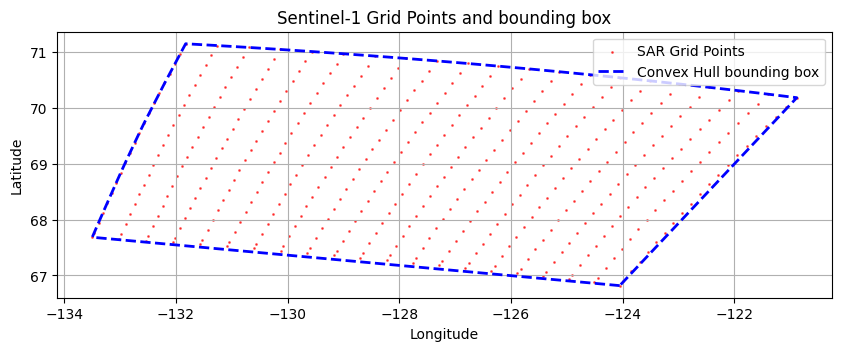

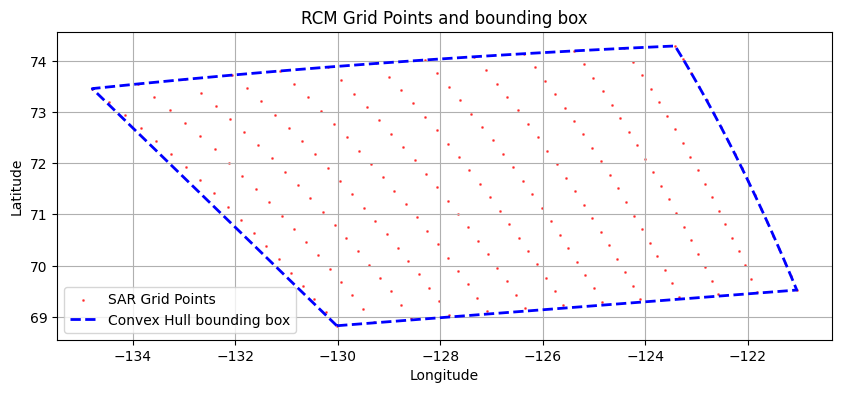

In [ ]:
test_path = "./new_AI4Arctic/S1A_EW_GRDM_1SDH_20200810T151258_20200810T151357_033846_03ECB0_0878_icechart_cis_SGRDIWA_20200810T1522Z_pl_a.nc"
ds = xr.open_dataset(test_path)
print(ds.dims)
for var_name in ds.variables:
    print(f" - {var_name} → {ds[var_name].dims} | shape: {ds[var_name].shape}")


# sentinel plot
lat = ds['sar_grid_latitude'].values
lon = ds['sar_grid_longitude'].values
lat_flat = lat.flatten()
lon_flat = lon.flatten()
valid_mask = np.isfinite(lat_flat) & np.isfinite(lon_flat)
lat_flat = lat_flat[valid_mask]
lon_flat = lon_flat[valid_mask]
points = MultiPoint(list(zip(lon_flat, lat_flat)))
hull = points.convex_hull  
gdf = gpd.GeoDataFrame(index=[0], geometry=[hull])
fig, ax = plt.subplots(figsize=(10, 10))
ax.scatter(lon_flat, lat_flat, s=1, color='red', label="SAR Grid Points", alpha=0.6)
gdf.boundary.plot(ax=ax, color='blue', linewidth=2, linestyle='--', label="Convex Hull bounding box")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Sentinel-1 Grid Points and bounding box")
ax.grid(True)
ax.legend()
plt.show()


# sentinel plot
lat = ds['sar_grid_latitude_rcm'].values
lon = ds['sar_grid_longitude_rcm'].values
lat_flat = lat.flatten()
lon_flat = lon.flatten()
valid_mask = np.isfinite(lat_flat) & np.isfinite(lon_flat)
lat_flat = lat_flat[valid_mask]
lon_flat = lon_flat[valid_mask]
points = MultiPoint(list(zip(lon_flat, lat_flat)))
hull = points.convex_hull  
gdf = gpd.GeoDataFrame(index=[0], geometry=[hull])
fig, ax = plt.subplots(figsize=(10, 10))
ax.scatter(lon_flat, lat_flat, s=1, color='red', label="SAR Grid Points", alpha=0.6)
gdf.boundary.plot(ax=ax, color='blue', linewidth=2, linestyle='--', label="Convex Hull bounding box")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("RCM Grid Points and bounding box")
ax.grid(True)
ax.legend()
plt.show()